In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [5]:
input_size = 28*28
hidden1 = 256
hidden2 = 128
num_classes = 10
num_epochs = 10
batch_size = 64
learning_rate = 0.001



In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [11]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)


In [13]:
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


In [15]:
# Define MLP model
class MLP(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, num_classes):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)

    def forward(self, x):
        x = x.view(-1, input_size)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [17]:
model = MLP(input_size, hidden1, hidden2, num_classes).to(device)


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [21]:
train_losses, test_losses, accuracies = [], [], []
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Evaluation on test set
    model.eval()
    correct, total, test_loss = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_losses.append(test_loss / len(test_loader))
    accuracy = 100 * correct / total
    accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {train_losses[-1]:.4f}, Test Acc: {accuracy:.2f}%")


Epoch [1/10], Loss: 0.3324, Test Acc: 94.45%
Epoch [2/10], Loss: 0.1487, Test Acc: 96.28%
Epoch [3/10], Loss: 0.1102, Test Acc: 97.36%
Epoch [4/10], Loss: 0.0880, Test Acc: 96.80%
Epoch [5/10], Loss: 0.0776, Test Acc: 96.73%
Epoch [6/10], Loss: 0.0647, Test Acc: 96.58%
Epoch [7/10], Loss: 0.0582, Test Acc: 97.10%
Epoch [8/10], Loss: 0.0536, Test Acc: 97.40%
Epoch [9/10], Loss: 0.0474, Test Acc: 97.26%
Epoch [10/10], Loss: 0.0422, Test Acc: 97.24%


In [23]:
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.98      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.93      0.99      0.95      1010
           4       0.95      0.98      0.97       982
           5       0.99      0.97      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.94      0.96      1028
           8       0.98      0.96      0.97       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



Text(0.5, 1.0, 'Loss Curve')

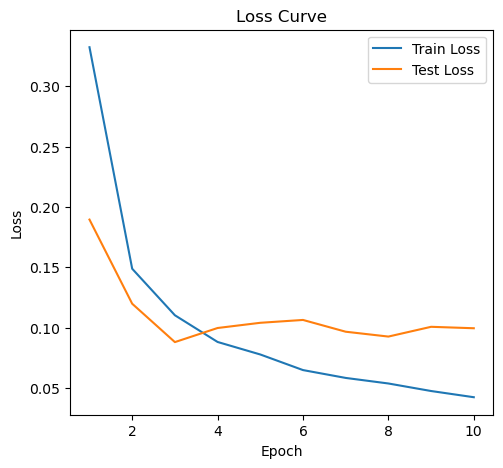

In [25]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

Text(0.5, 1.0, 'Accuracy Curve')

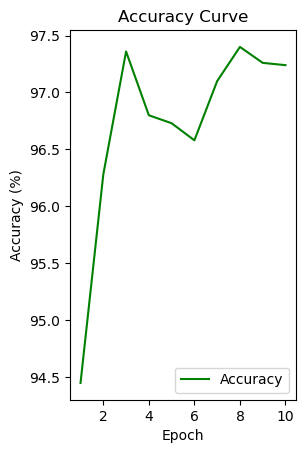

In [27]:
plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), accuracies, label='Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy Curve')

In [29]:
plt.show()
